# CCO14: Re-process Bulk RNA-seq

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

from sklearn.decomposition import PCA

import gseapy as gp

In [6]:
WORK_DIR = "/home/herbert/work/cocultured_organ/workspace/CCO14"
DATA_DIR = "/home/herbert/work/cocultured_organ/data/220720"

In [7]:
os.system(f"mkdir -p {WORK_DIR}")

0

In [8]:
group_names = ["HOWT_1", "HOWT_2", "HOWT_3", "HOET_1", "HOET_2", "HOET_3", ]

# 0. collect data

In [30]:
os.system(f"mkdir -p {WORK_DIR}/data")

0

In [28]:
df = None

for group_name in group_names:
    df_sub = pd.read_csv(f"{DATA_DIR}/{group_name}-JL-0308.counts.genes", header=None, index_col=0, sep='\t')
    df_sub = df_sub.set_axis([group_name, ], axis=1)

    if df is None:
        df = df_sub.copy()
    else:
        df = pd.merge(df, df_sub, left_index=True, right_index=True, how='outer').fillna(0)

In [31]:
df.to_csv(f"{WORK_DIR}/data/raw.tsv", sep='\t')

# 1.

In [10]:
df = pd.read_csv(f"{WORK_DIR}/data/raw.tsv", sep='\t', header=0, index_col=0)
print(df.shape)
df.head()

(26366, 6)


,HOWT_1,HOWT_2,HOWT_3,HOET_1,HOET_2,HOET_3
0,,,,,,
DDX11L1,0,0,2,0,0,4
WASH7P,150,121,120,90,120,126
MIR6859-3,0,0,0,0,0,0
MIR6859-2,0,0,0,0,0,0
MIR6859-4,0,0,0,0,0,0


In [11]:
summary_rows = [
    "no_feature",
    "ambiguous",
    "not_aligned",
    "alignment_not_unique",
    "__no_feature",
    "__ambiguous",
    "__not_aligned",
    "__alignment_not_unique",
]

counts = df.drop(index=summary_rows, errors="ignore").copy()

# Make sure everything is numeric
counts = counts.apply(pd.to_numeric)

# Remove completely unexpressed genes
counts = counts.loc[counts.sum(axis=1) > 0]
counts = counts.loc[counts.sum(axis=1) >= 10]

print(counts.shape)
counts.head()

(17112, 6)


,HOWT_1,HOWT_2,HOWT_3,HOET_1,HOET_2,HOET_3
0,,,,,,
WASH7P,150,121,120,90,120,126
LOC729737,590,462,522,736,984,1079
LOC100133331,173,133,172,84,124,160
LOC100288069,151,148,204,73,144,126
LINC00115,21,20,15,81,109,101


In [13]:
counts_deseq = counts.T
print(counts_deseq.shape)
counts_deseq.head()

(6, 17112)


0,WASH7P,LOC729737,LOC100133331,LOC100288069,LINC00115,LINC01128,LOC100130417,SAMD11,NOC2L,KLHL17,...,UTY,TMSB4Y,NLGN4Y,TTTY14,CD24,BCORP1,TXLNGY,KDM5D,TTTY10,EIF1AY
HOWT_1,150,590,173,151,21,1704,363,711,1627,171,...,681,62,297,82,2413,10,812,1940,5,660
HOWT_2,121,462,133,148,20,1173,373,710,1340,142,...,445,68,219,83,2008,5,550,1525,2,536
HOWT_3,120,522,172,204,15,1596,360,724,1597,149,...,597,53,281,99,1967,3,639,1740,5,629
HOET_1,90,736,84,73,81,1130,59,336,922,259,...,714,15,146,122,1102,3,410,1010,2,807
HOET_2,120,984,124,144,109,1110,112,496,1170,395,...,723,19,144,133,1448,3,399,1042,3,1117


In [14]:
metadata = pd.DataFrame(
    {
        "condition": [
            "WT", "WT", "WT",
            "ET", "ET", "ET"
        ]
    },
    index=counts_deseq.index,
)

In [15]:
dds = DeseqDataSet(
    counts=counts_deseq,
    metadata=metadata,
    design="~condition",
)

dds.deseq2()

Fitting size factors...
... done in 0.06 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.56 seconds.

Fitting dispersion trend curve...
... done in 0.25 seconds.

Fitting MAP dispersions...
... done in 0.53 seconds.

Fitting LFCs...
... done in 0.94 seconds.

Calculating cook's distance...
... done in 0.10 seconds.

Replacing 0 outlier genes.



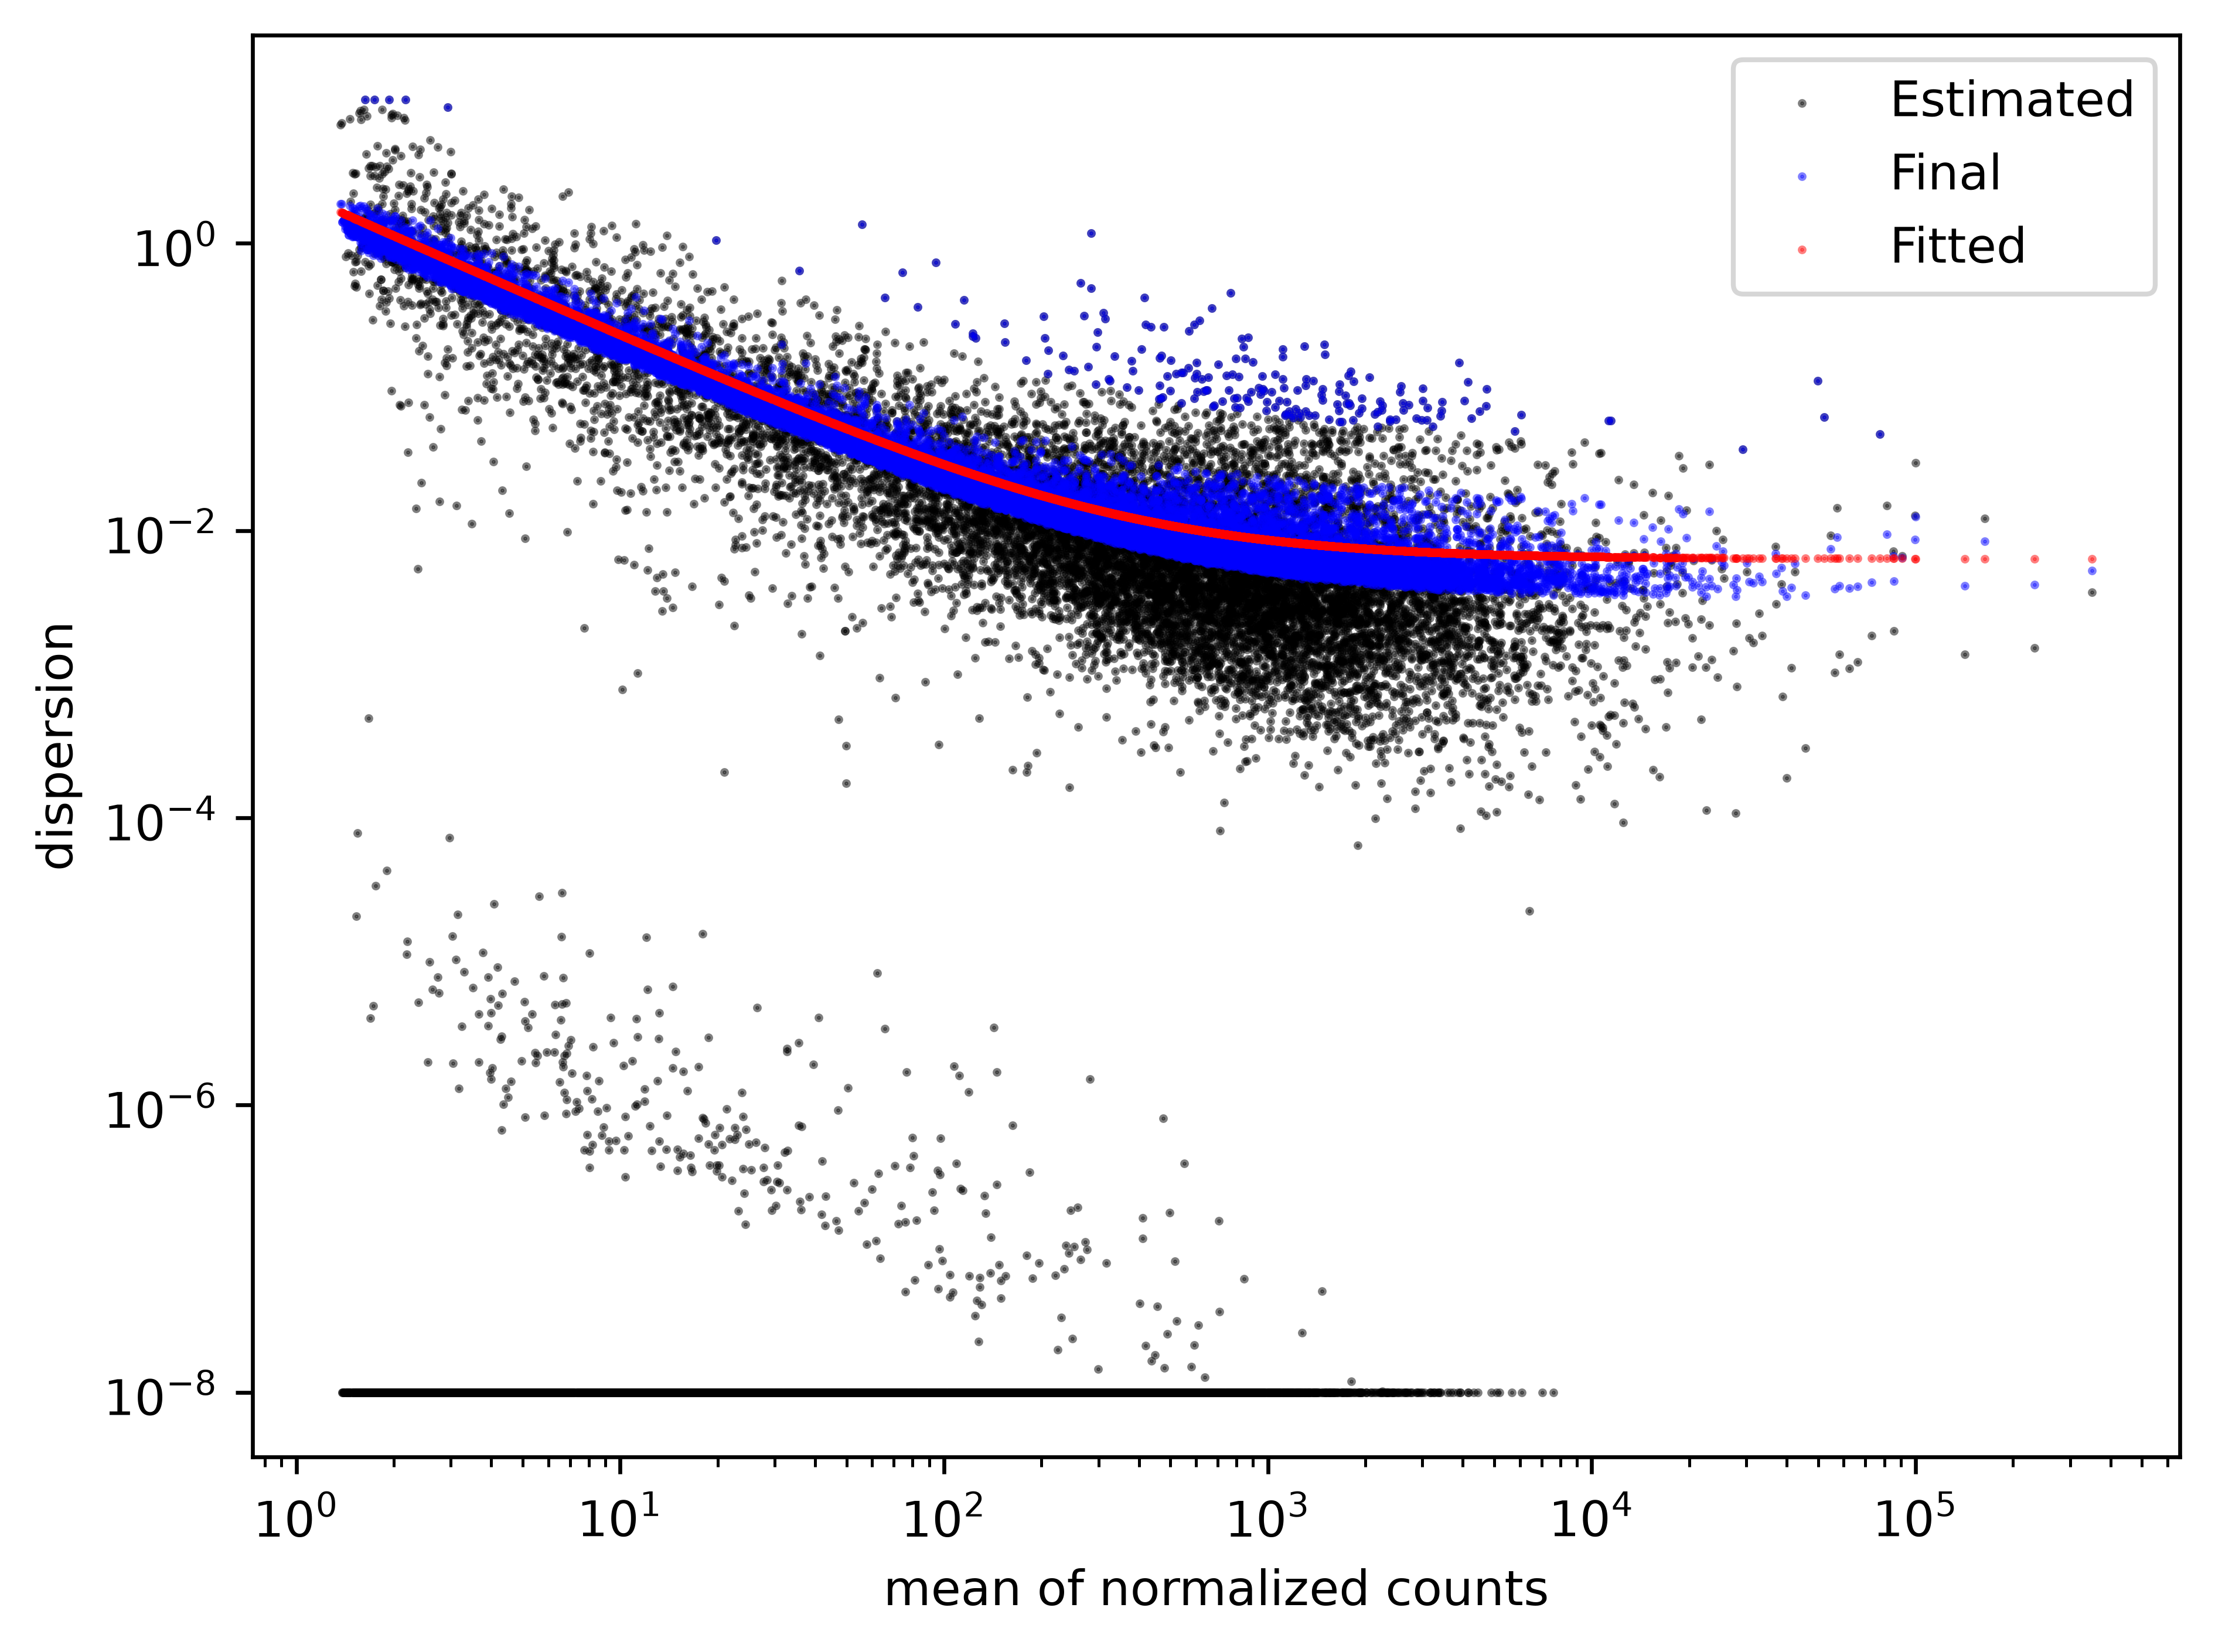

In [17]:
dds.plot_dispersions()

## 1.1 PCA

In [18]:
dds.vst()

vst = pd.DataFrame(
    dds.layers["vst_counts"],
    index=dds.obs_names,
    columns=dds.var_names,
)

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.48 seconds.



In [19]:
pca = PCA(n_components=2)

pcs = pca.fit_transform(vst)

pca_df = pd.DataFrame(
    pcs,
    columns=["PC1", "PC2"],
    index=vst.index,
)

pca_df["condition"] = metadata["condition"]

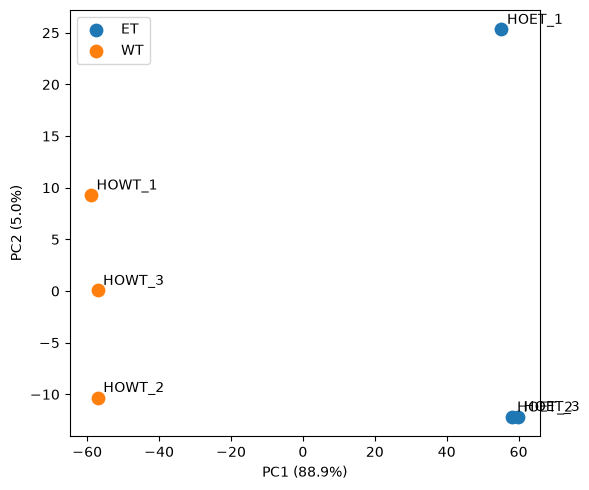

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))

for condition, group in pca_df.groupby("condition"):
    ax.scatter(
        group["PC1"],
        group["PC2"],
        s=80,
        label=condition
    )

for sample, row in pca_df.iterrows():
    ax.annotate(
        sample,
        (row["PC1"], row["PC2"]),
        xytext=(4, 4),
        textcoords="offset points"
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

ax.legend()
plt.tight_layout()
plt.show()

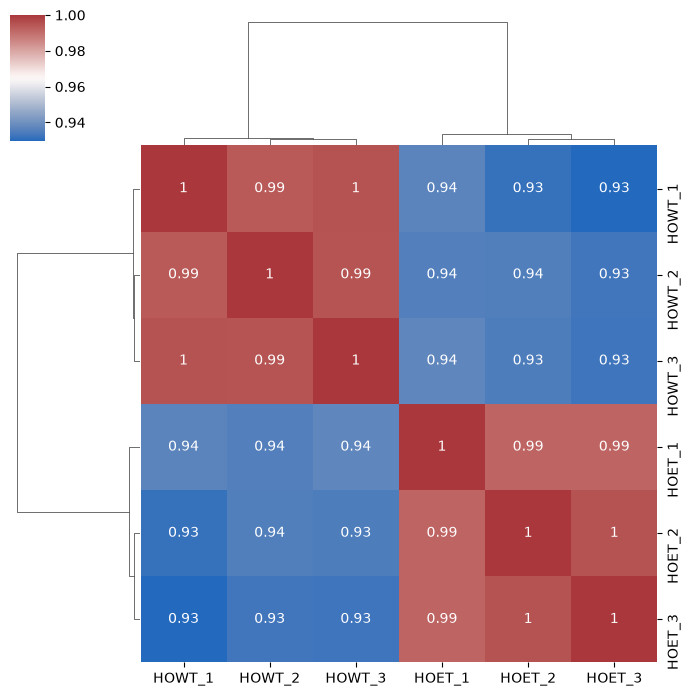

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = vst.T.corr()

sns.clustermap(
    corr,
    cmap="vlag",
    annot=True,
    figsize=(7, 7)
)

plt.show()

## 1.2 DEG

In [31]:
FC = 1
FDR = 0.01

In [32]:
stat_res = DeseqStats(
    dds,
    contrast=["condition", "ET", "WT"],
)

stat_res.summary()

Running Wald tests...
... done in 7.83 seconds.



Log2 fold change & Wald test p-value: condition ET vs WT
                 baseMean  log2FoldChange     lfcSE       stat        pvalue  \
0                                                                              
WASH7P         119.542673        0.172857  0.191362   0.903300  3.663666e-01   
LOC729737      753.165349        1.220824  0.117113  10.424352  1.919642e-25   
LOC100133331   137.618676        0.009788  0.206310   0.047444  9.621591e-01   
LOC100288069   136.848547       -0.180730  0.225197  -0.802544  4.222383e-01   
LINC00115       62.985854        2.766370  0.296638   9.325759  1.101921e-20   
...                   ...             ...       ...        ...           ...   
BCORP1           4.428040       -0.428309  0.919297  -0.465910  6.412802e-01   
TXLNGY         514.789258       -0.324922  0.127805  -2.542328  1.101166e-02   
KDM5D         1353.083921       -0.307259  0.094299  -3.258361  1.120578e-03   
TTTY10           3.192621       -0.175787  1.048466  -0.167661 

In [33]:
res = stat_res.results_df.copy()
sig = res[
    (res["padj"] < FDR) &
    (res["log2FoldChange"].abs() >= FC)
].copy()

sig = sig.sort_values("padj")
up = sig[sig["log2FoldChange"] >= FC]
down = sig[sig["log2FoldChange"] <= -FC]

In [34]:
# res.to_csv("DESeq2_ET_vs_WT_all.csv")
# sig.to_csv("DESeq2_ET_vs_WT_DEGs.csv")

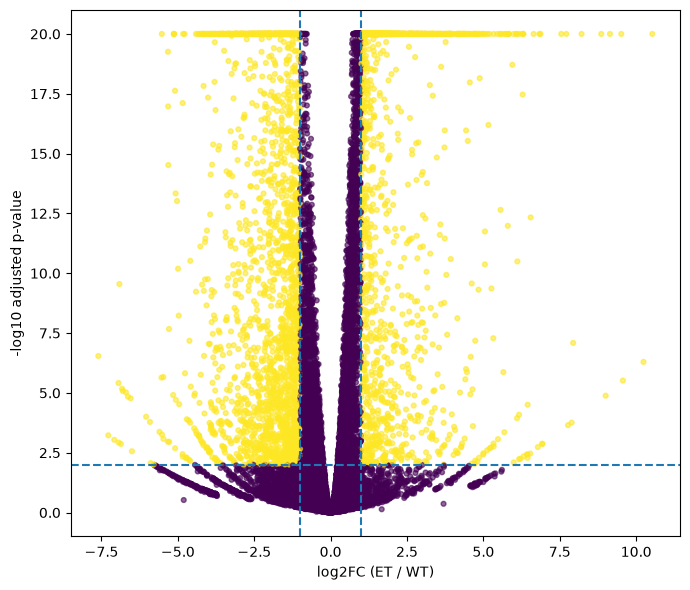

In [38]:
plot_df = res.dropna(subset=["padj"]).copy()

plot_df["minus_log10_padj"] = -np.log10(
    plot_df["padj"].clip(lower=1e-20)
)

plot_df["significant"] = (
    (plot_df["padj"] < FDR) &
    (plot_df["log2FoldChange"].abs() >= FC)
)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    plot_df["log2FoldChange"],
    plot_df["minus_log10_padj"],
    c=plot_df["significant"],
    s=12,
    alpha=0.6
)

ax.axvline(-1, linestyle="--")
ax.axvline(1, linestyle="--")
ax.axhline(-np.log10(FDR), linestyle="--")

ax.set_xlabel("log2FC (ET / WT)")
ax.set_ylabel("-log10 adjusted p-value")

plt.tight_layout()
plt.show()

## 1.3

In [39]:
ranking = (
    res["stat"]
    .dropna()
    .sort_values(ascending=False)
)

rnk = ranking.reset_index()
rnk.columns = ["gene", "score"]

In [42]:
pre_res = gp.prerank(
    rnk=rnk,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    min_size=15,
    max_size=500,
    permutation_num=1000,
    outdir=None,
    seed=42,
)

2026-08-19 06:28:38,891 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [44]:
gsea_results = pre_res.res2d

gsea_results.head(20)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,E2F Targets,-0.712981,-3.295174,0.0,0.000000,0.000,101/195,8.92%,MKI67;TOP2A;RRM2;MYBL2;STMN1;MCM2;BUB1B;MCM5;K...
1,prerank,G2-M Checkpoint,-0.703265,-3.176739,0.0,0.000000,0.000,91/187,7.88%,MKI67;TOP2A;NUSAP1;MYBL2;KIF11;CENPF;STMN1;MCM...
2,prerank,Hypoxia,0.732395,2.668913,0.0,0.000000,0.000,94/182,11.55%,ENO2;IER3;STC1;GBE1;HK2;PIM1;FOS;BHLHE40;DUSP1...
3,prerank,TNF-alpha Signaling via NF-kB,0.723414,2.619755,0.0,0.000000,0.000,82/177,11.55%,NR4A1;RCAN1;IER3;HBEGF;FOS;BHLHE40;LDLR;GADD45...
4,prerank,Oxidative Phosphorylation,0.707033,2.546366,0.0,0.000000,0.000,122/184,17.65%,SLC25A4;VDAC2;MPC1;IDH3A;SLC25A3;MDH1;ATP6V1D;...
5,prerank,Myogenesis,0.690298,2.505143,0.0,0.000000,0.000,83/186,13.15%,ACTA1;CRYAB;TAGLN;ACTN2;SLN;FHL1;MYH7;HBEGF;FA...
6,prerank,Cholesterol Homeostasis,0.661880,2.155063,0.0,0.000000,0.000,32/72,10.23%,TNFRSF12A;LDLR;ATF3;SCD;NFIL3;SQLE;HMGCS1;MVD;...
7,prerank,mTORC1 Signaling,0.580249,2.121580,0.0,0.000000,0.000,76/195,11.44%,STC1;GBE1;HK2;INSIG1;BHLHE40;LDLR;PPP1R15A;CDK...
8,prerank,Epithelial Mesenchymal Transition,0.579242,2.101193,0.0,0.000000,0.000,62/184,10.92%,THBS1;COL1A2;TAGLN;ENO2;COL4A1;TNFRSF12A;FSTL3...
9,prerank,Androgen Response,0.618519,2.078549,0.0,0.000000,0.000,44/92,16.49%,INSIG1;NDRG1;ACTN1;MYL12A;SCD;STK39;NGLY1;HMGC...
